<a href="https://colab.research.google.com/github/Goyallgithub/ThermalCVD_BayesianOptimization_Results/blob/main/WS2_CVD_Bayesian_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 Bayesian Optimization for WS₂ Synthesis via Thermal CVD
## Active Learning Framework — Predicting PL FWHM

---
**Meeting Notes — 16/05/2026 | Bhavya Discussion**

> **Goal:** Minimize the Photoluminescence (PL) Full Width at Half Maximum (FWHM) of synthesized WS₂ films using Bayesian Optimization (BO). A lower FWHM indicates higher crystal quality and fewer defects.

**Pipeline Overview:**
1. 📤 Upload your experimental Excel sheet
2. 🔍 Auto-detect Thermal CVD experiments
3. 🏷️ Encode constants (categorical + numerical) and define variable search space
4. 🤖 Fit Gaussian Process surrogate model
5. 📊 Visualize GP + Acquisition Function
6. 🔄 Active Learning loop — suggest next experiment

---

## 📦 Step 0: Install & Import Libraries

In [1]:
# Install required packages
!pip install scikit-learn scipy numpy pandas openpyxl matplotlib seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import norm, qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import LeaveOneOut, cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
COLORS = {
    'primary': '#2E86AB',
    'secondary': '#A23B72',
    'accent': '#F18F01',
    'success': '#5C9E31',
    'danger': '#E84855',
    'bg': '#F7F9FC',
    'gp_mean': '#2E86AB',
    'gp_ci': '#AED6F1',
    'acq': '#F18F01',
    'obs': '#E84855',
    'next': '#5C9E31',
}
print('All libraries loaded successfully!')


✅ All libraries loaded successfully!


---
## 📤 Step 1: Upload Your Experimental Excel File

Your Excel sheet should contain CVD synthesis parameters. The model will automatically:
- Filter **Thermal CVD** experiments (column `TOCVD`)
- Identify constants and variables
- Handle categorical data via encoding


In [2]:
import io

print('Loading WS2 Thermal CVD database...')
print('   Required column: TOCVD (to filter Thermal CVD rows)')
print('   Target column:   PL FWHM (what we want to minimize)')
print()

# ── Load the 17-point dataset (same file used by the app) ──────────────────
file_name = 'WS2_ThermalCVD_BlankCells_17points.xlsx'
df_raw = pd.read_excel(file_name)

# Replace 'NS' (Not Specified) with NaN — matches app logic
df_raw = df_raw.replace('NS', np.nan)

# Handle PL FWHM column name variant
if 'PL_FWHM' not in df_raw.columns and 'PL FWHM' in df_raw.columns:
    df_raw = df_raw.rename(columns={'PL FWHM': 'PL_FWHM'})

print(f'\n✅ File loaded: {file_name}')
print(f'📊 Total rows: {len(df_raw)} | Total columns: {len(df_raw.columns)}')
print(f'   Columns: {list(df_raw.columns)}')


📂 Please upload your Excel file (.xlsx) containing the CVD synthesis database...
   Required column: TOCVD (to filter Thermal CVD rows)
   Target column:   PL FWHM (what we want to minimize)



Saving labelled (1).xlsx to labelled (1).xlsx

✅ File uploaded: labelled (1).xlsx
📊 Total rows: 21 | Total columns: 21
   Columns: ['P1', 'P2', 'CP1', 'CP2', 'FRP1', 'FRP2', 'SA', 'Substrate', 'CG', 'FRA', 'FRH', 'GTE', 'GTI', 'HR', 'Pressure', 'COM', 'PC', 'TOCVD', 'Class', 'PL Peak Position', 'PL FWHM']


---
## 🔍 Step 2: Filter Thermal CVD & Data Preview

In [3]:
# ─── Column name mapping (auto-detect or use defaults) ──────────────────────
COL_MAP = {
    'P1':          'P1',
    'P2':          'P2',
    'CP1':         'CP1',
    'CP2':         'CP2',
    'FRP1':        'FRP1',
    'FRP2':        'FRP2',
    'SA':          'SA',
    'Substrate':   'Substrate',
    'CG':          'CG',
    'FRA':         'FRA',
    'FRH':         'FRH',
    'GTE':         'GTE',
    'GTI':         'GTI',
    'HR':          'HR',
    'Pressure':    'Pressure',
    'COM':         'COM',
    'PC':          'PC',
    'TOCVD':       'TOCVD',
    'Class':       'Class',
    'PL_peak':     'PL Peak Position',
    'FWHM':        'PL_FWHM',
}

# Filter Thermal CVD — matches app: df[df['TOCVD'] == 'Thermal CVD']
if COL_MAP['TOCVD'] not in df_raw.columns:
    raise ValueError(f"Column '{COL_MAP['TOCVD']}' not found. Available: {list(df_raw.columns)}")

df = df_raw[df_raw[COL_MAP['TOCVD']] == 'Thermal CVD'].copy().reset_index(drop=True)

# Coerce known numeric columns (matches app logic)
num_cols = ['FRH', 'HR', 'FRP1', 'FRP2', 'CP1', 'CP2', 'GTE', 'GTI', 'FRA', 'Pressure', 'PL_FWHM']
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'🧪 Thermal CVD experiments found: {len(df)}')
print(f'   FWHM range: {df[COL_MAP["FWHM"]].min()} – {df[COL_MAP["FWHM"]].max()} meV')
print()

display(df.style.set_caption('Thermal CVD Experiments (Your Database)').background_gradient(
    subset=[COL_MAP['FWHM']], cmap='RdYgN_r'))


🧪 Thermal CVD experiments found: 7
   FWHM range: 21 – 124 meV



,P1,P2,CP1,CP2,FRP1,FRP2,SA,Substrate,CG,FRA,FRH,GTE,GTI,HR,Pressure,COM,PC,TOCVD,Class,PL Peak Position,PL FWHM
0,WO3,Sulfur,35.000000,2000.000000,nan,nan,nan,graphite,Ar,100.000000,0,1000,20.000000,15.000000,730.000000,Rapid,Quartz boat,Thermal CVD,Monolayer,1.990000,21
1,WCl6,Sulfur,200.000000,800.000000,nan,nan,nan,SiO2/Si,Ar,2.500000,0,800,15.000000,15.000000,nan,Natural,Al2O3 crucible,Thermal CVD,Nanosheets,2.014000,124
2,W(CO)6,H2S,nan,nan,0.000170,7.000000,nan,Sapphire (C-plane),H2,0.000000,200,800,30.000000,nan,50.000000,nan,Bubbler,Thermal CVD,nan,1.990000,60
3,W(CO)6,DTBS,nan,nan,0.007350,7.280000,nan,SiO2/Si,H2/Ar,500.000000,25,850,nan,20.000000,50.000000,nan,Bubbler,Thermal CVD,nan,2.010000,69
4,W(CO)6,Sulfur,nan,nan,nan,nan,nan,Graphene,He,0.000000,0,600,nan,nan,nan,nan,Sulfur boat,Thermal CVD,nan,1.990000,27
5,WF6,H2S,nan,nan,0.025000,0.330000,NaCl,SiO2/Si,Ar,100.000000,0,640,40.000000,nan,7.500000,nan,Ceramic boat,Thermal CVD,nan,1.970000,48
6,WF6,H2S,nan,nan,nan,nan,SnCl4,SiO2/Si,Ar,nan,0,550,nan,nan,30.000000,nan,Gas cylinders,Thermal CVD,nan,2.010000,60


---
## 🏷️ Step 3: Constants & Variables — Classification

### What are Constants vs Variables?
- **Constants** = parameters that are fixed for this experimental run (substrate type, carrier gas, precursor choice, etc.)
- **Variables** = parameters we will vary/optimize (temperature, time, flow rate, pressure)

Constants are **encoded** (even if fixed now) so the model can handle different setups in future runs.


In [4]:
# ─── EXACT SAME CONSTANTS & VARIABLES AS THE APP ────────────────────────────
# (Matches ThermalCVDEncoder in app/ml_models/thermal_cvd/data_encoder.py)

# Categorical constants (8) — Note: TOCVD excluded (already filtered)
CAT_CONSTANTS = ['P1', 'P2', 'Substrate', 'CG', 'COM', 'PC', 'SA', 'Class']

# Numerical constants — stored for reference only, NOT in feature matrix
NUM_CONSTANTS = ['FRH', 'HR', 'FRP1', 'FRP2', 'CP1', 'CP2']

# Variables — the 4 parameters swept by Bayesian Optimization
VARIABLES = ['GTE', 'GTI', 'FRA', 'Pressure']

# Variable bounds — EXACT same as app's VARIABLE_RANGES
VARIABLE_RANGES = {
    'GTE':      (500, 1100),   # Growth Temperature [°C]
    'GTI':      (5, 60),       # Growth Time [min]
    'FRA':      (0, 100),      # Ar Flow Rate [sccm]
    'Pressure': (1, 760),      # Chamber Pressure [Torr]
}

TARGET = 'PL_FWHM'

print('=' * 60)
print('📊 PARAMETER CLASSIFICATION SUMMARY (Matches App)')
print('=' * 60)
print(f'
🔒 Categorical Constants ({len(CAT_CONSTANTS)}): {CAT_CONSTANTS}')
print(f'🔢 Numerical Constants ({len(NUM_CONSTANTS)}): {NUM_CONSTANTS}')
print(f'
🎯 Optimization Variables ({len(VARIABLES)}):')
for v, (lo, hi) in VARIABLE_RANGES.items():
    obs = df[v].dropna().tolist()
    print(f'   {v:12s} | Range: [{lo:6} – {hi:6}] | Observed: {obs}')
print(f'
🎯 Target: {TARGET} (meV) — we want to MINIMIZE this!')
print('=' * 60)


📊 PARAMETER CLASSIFICATION SUMMARY

🔒 Categorical Constants (8):
   P1           | Fixed at: 'W(CO)6'             | Options: ['WO3', 'WCl6', 'W(CO)6', 'WF6']
   P2           | Fixed at: 'H2S'                | Options: ['Sulfur', 'H2S', 'DTBS']
   Substrate    | Fixed at: 'SiO2/Si'            | Options: ['graphite', 'SiO2/Si', 'Sapphire (C-plane)', 'Graphene']
   CG           | Fixed at: 'Ar'                 | Options: ['Ar', 'H2', 'H2/Ar', 'He']
   COM          | Fixed at: 'Natural'            | Options: ['Rapid', 'Natural']
   PC           | Fixed at: 'Bubbler'            | Options: ['Quartz boat', 'Al2O3 crucible', 'Bubbler', 'Sulfur boat', 'Ceramic boat', 'Gas cylinders']
   SA           | Fixed at: 'NaCl'               | Options: ['NaCl', 'SnCl4']
   Class        | Fixed at: 'Monolayer'          | Options: ['Monolayer', 'Nanosheets']

🔢 Numerical Constants (1):
   FRH          | Fixed at: 0.0 sccm | H₂ flow rate

🎯 Optimization Variables (4):
   GTE          | Range: [   500 –   11

---
## 🔠 Step 4: Categorical Encoding — Label Encoding with Visual

### Why Encode Categorical Constants?
Machine learning models work with numbers. We encode categorical variables so that:
1. The model can process them mathematically
2. **When constants change** (e.g., switching substrate), the encoding updates and the GP adapts
3. Future multi-setup experiments can be handled seamlessly


In [5]:
# ─── STEP 4: ENCODE — Matches app's ThermalCVDEncoder.fit_on_data() ─────────

# 1. Fit categorical LabelEncoders (fill NaN with 'Unknown')
label_encoders = {}
constant_values = {}

for col in CAT_CONSTANTS:
    series = df[col].fillna('Unknown').astype(str)
    le = LabelEncoder()
    le.fit(series.unique())
    label_encoders[col] = le
    constant_values[col] = series.mode()[0]
    print(f'   {col:12s} | Fixed at: {repr(constant_values[col]):20s} | Options: {list(le.classes_)}')

# 2. Store numerical constant medians for reference
for col in NUM_CONSTANTS:
    if col in df.columns:
        val = pd.to_numeric(df[col], errors='coerce').dropna()
        constant_values[col] = float(val.median()) if len(val) > 0 else 0.0
    else:
        constant_values[col] = 0.0

print()


✅ Label Encoding Complete!

📋 Encoding Dictionary:
   P1: {'W(CO)6': np.int64(0), 'WCl6': np.int64(1), 'WF6': np.int64(2), 'WO3': np.int64(3)}
   P2: {'DTBS': np.int64(0), 'H2S': np.int64(1), 'Sulfur': np.int64(2)}
   Substrate: {'Graphene': np.int64(0), 'Sapphire (C-plane)': np.int64(1), 'SiO2/Si': np.int64(2), 'graphite': np.int64(3)}
   CG: {'Ar': np.int64(0), 'H2': np.int64(1), 'H2/Ar': np.int64(2), 'He': np.int64(3)}
   COM: {'Natural': np.int64(0), 'Rapid': np.int64(1), 'Unknown': np.int64(2)}
   PC: {'Al2O3 crucible': np.int64(0), 'Bubbler': np.int64(1), 'Ceramic boat': np.int64(2), 'Gas cylinders': np.int64(3), 'Quartz boat': np.int64(4), 'Sulfur boat': np.int64(5)}
   SA: {'NaCl': np.int64(0), 'SnCl4': np.int64(1), 'Unknown': np.int64(2)}
   Class: {'Monolayer': np.int64(0), 'Nanosheets': np.int64(1), 'Unknown': np.int64(2)}


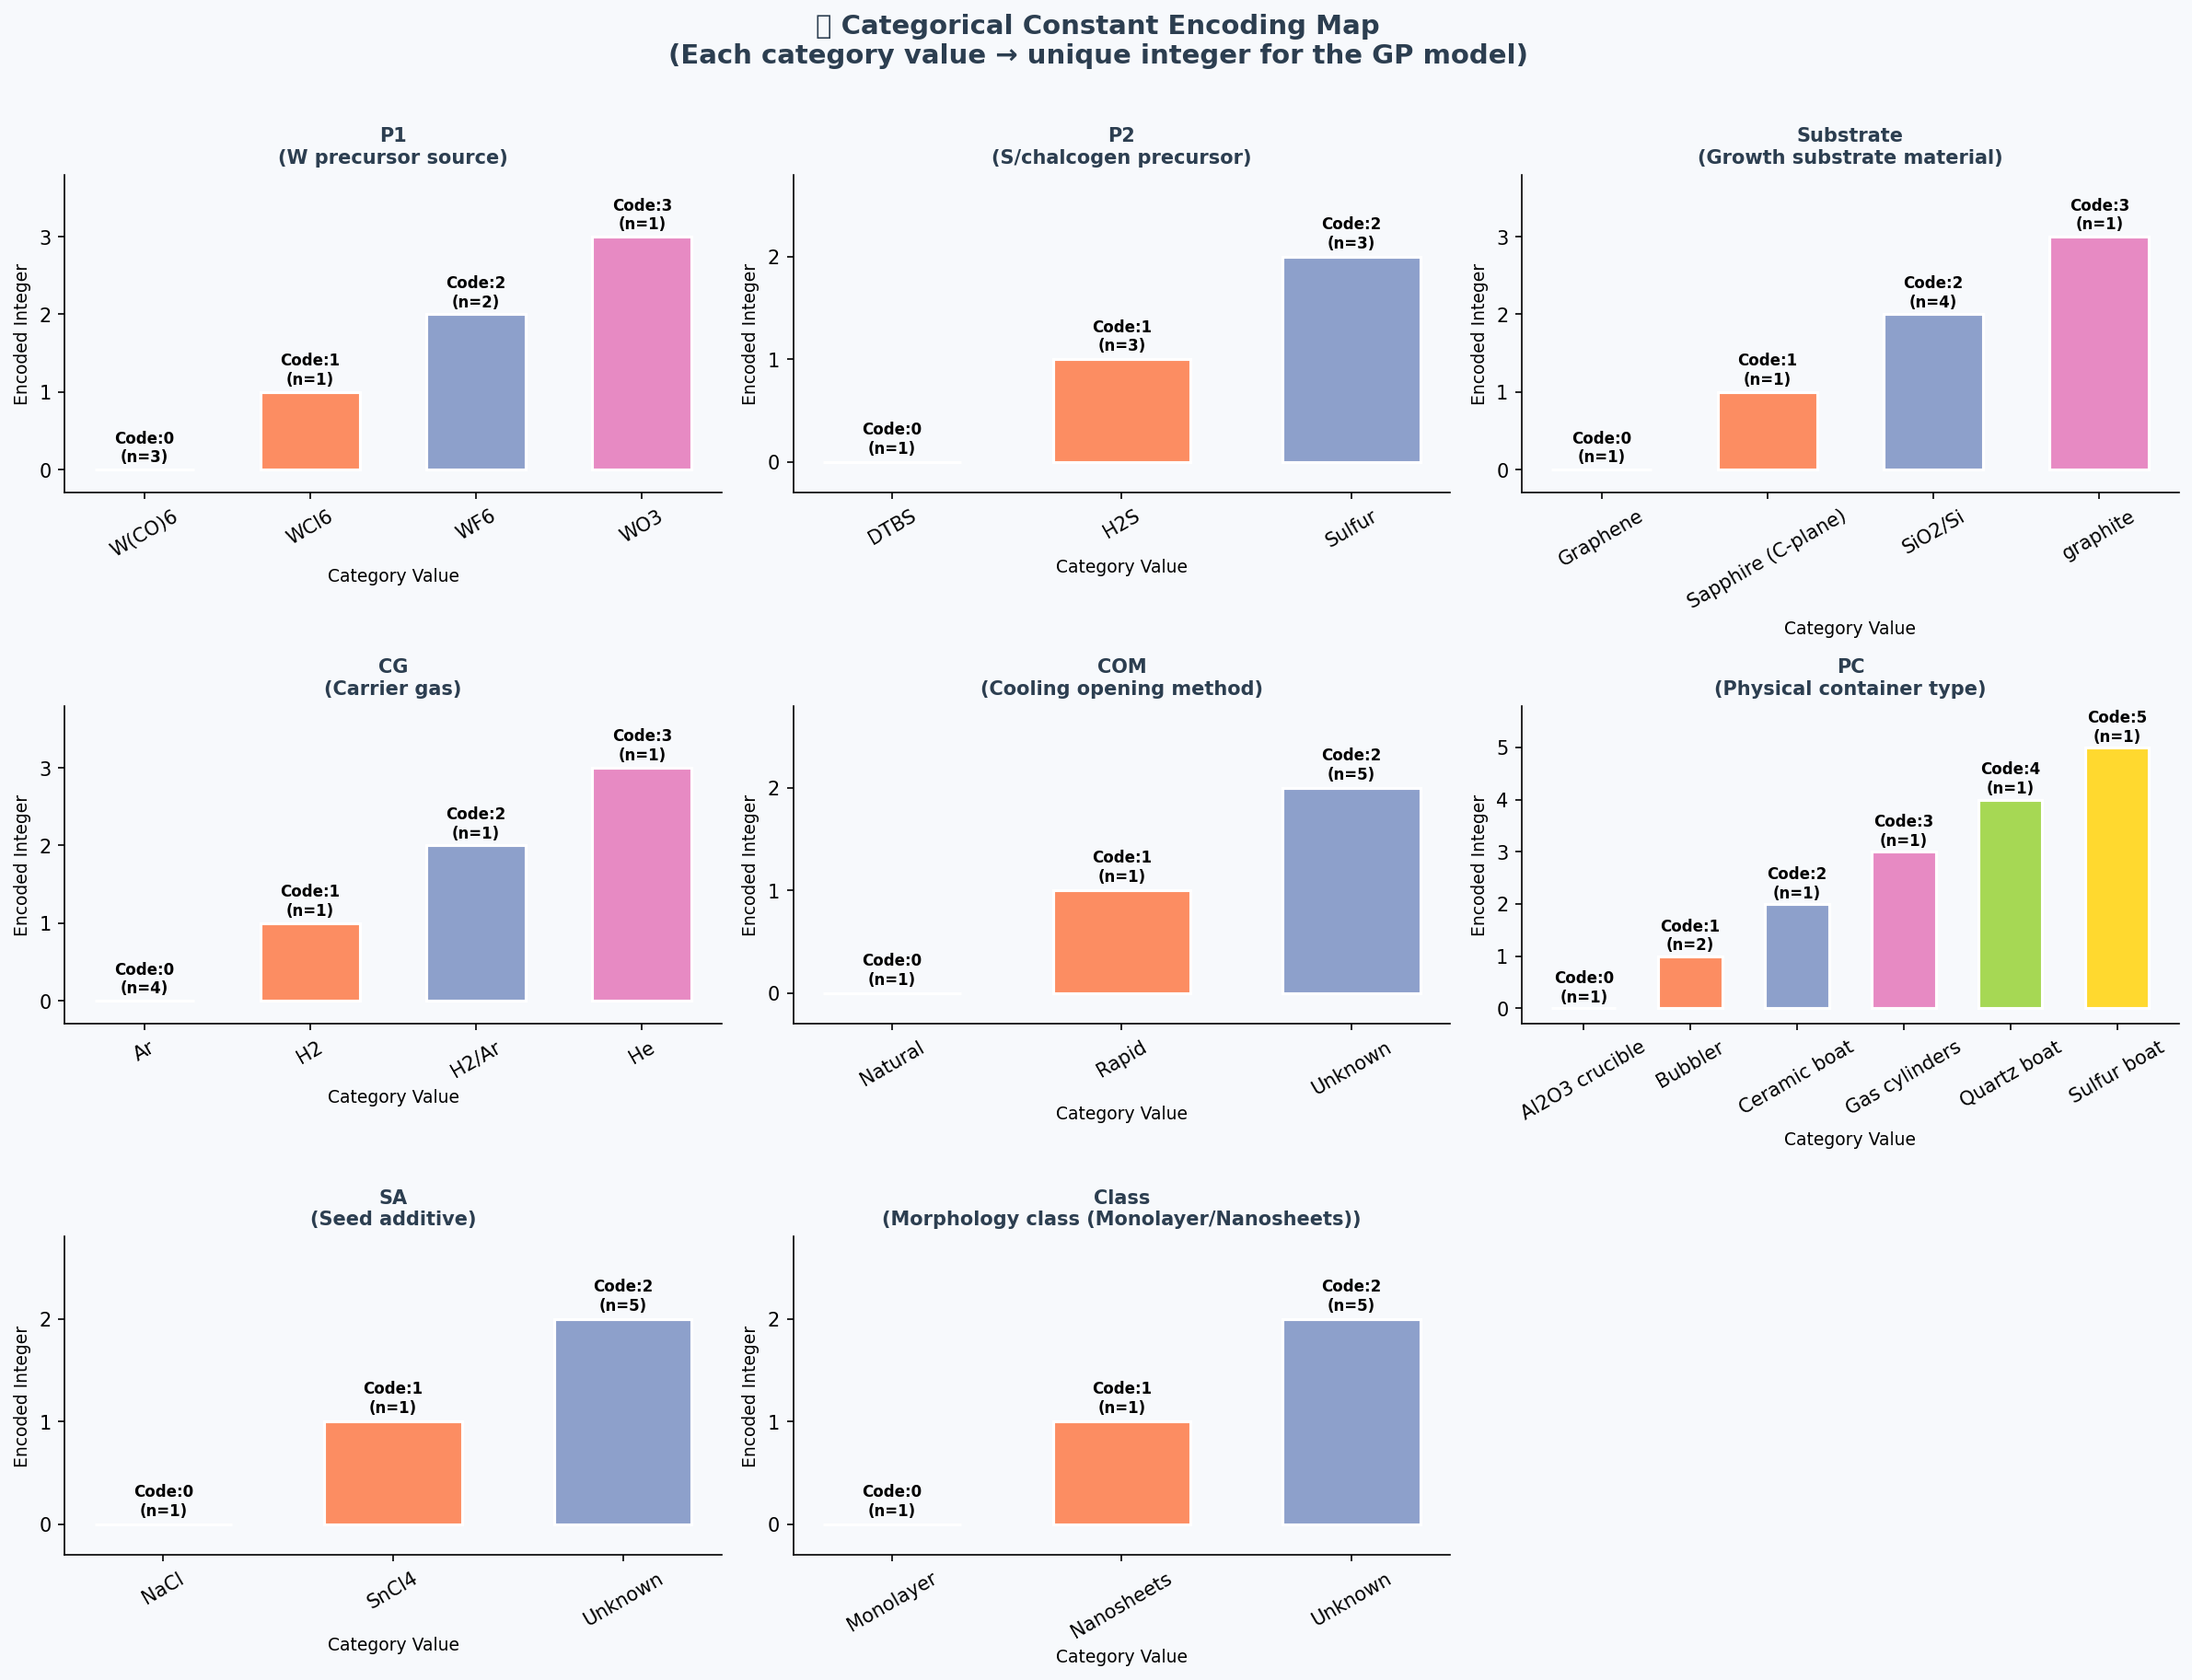


💡 Insight: These codes are fed into the GP model as context features.
   When you change substrate from SiO2/Si → Sapphire, only the code changes!


In [6]:
# ─── STEP 4: ENCODE — Matches app's ThermalCVDEncoder.fit_on_data() ─────────

# 1. Fit categorical LabelEncoders (fill NaN with 'Unknown')
label_encoders = {}
constant_values = {}

for col in CAT_CONSTANTS:
    series = df[col].fillna('Unknown').astype(str)
    le = LabelEncoder()
    le.fit(series.unique())
    label_encoders[col] = le
    constant_values[col] = series.mode()[0]
    print(f'   {col:12s} | Fixed at: {repr(constant_values[col]):20s} | Options: {list(le.classes_)}')

# 2. Store numerical constant medians for reference
for col in NUM_CONSTANTS:
    if col in df.columns:
        val = pd.to_numeric(df[col], errors='coerce').dropna()
        constant_values[col] = float(val.median()) if len(val) > 0 else 0.0
    else:
        constant_values[col] = 0.0

print()


---
## 📊 Step 5: Visualization of Constants & Variables Distribution

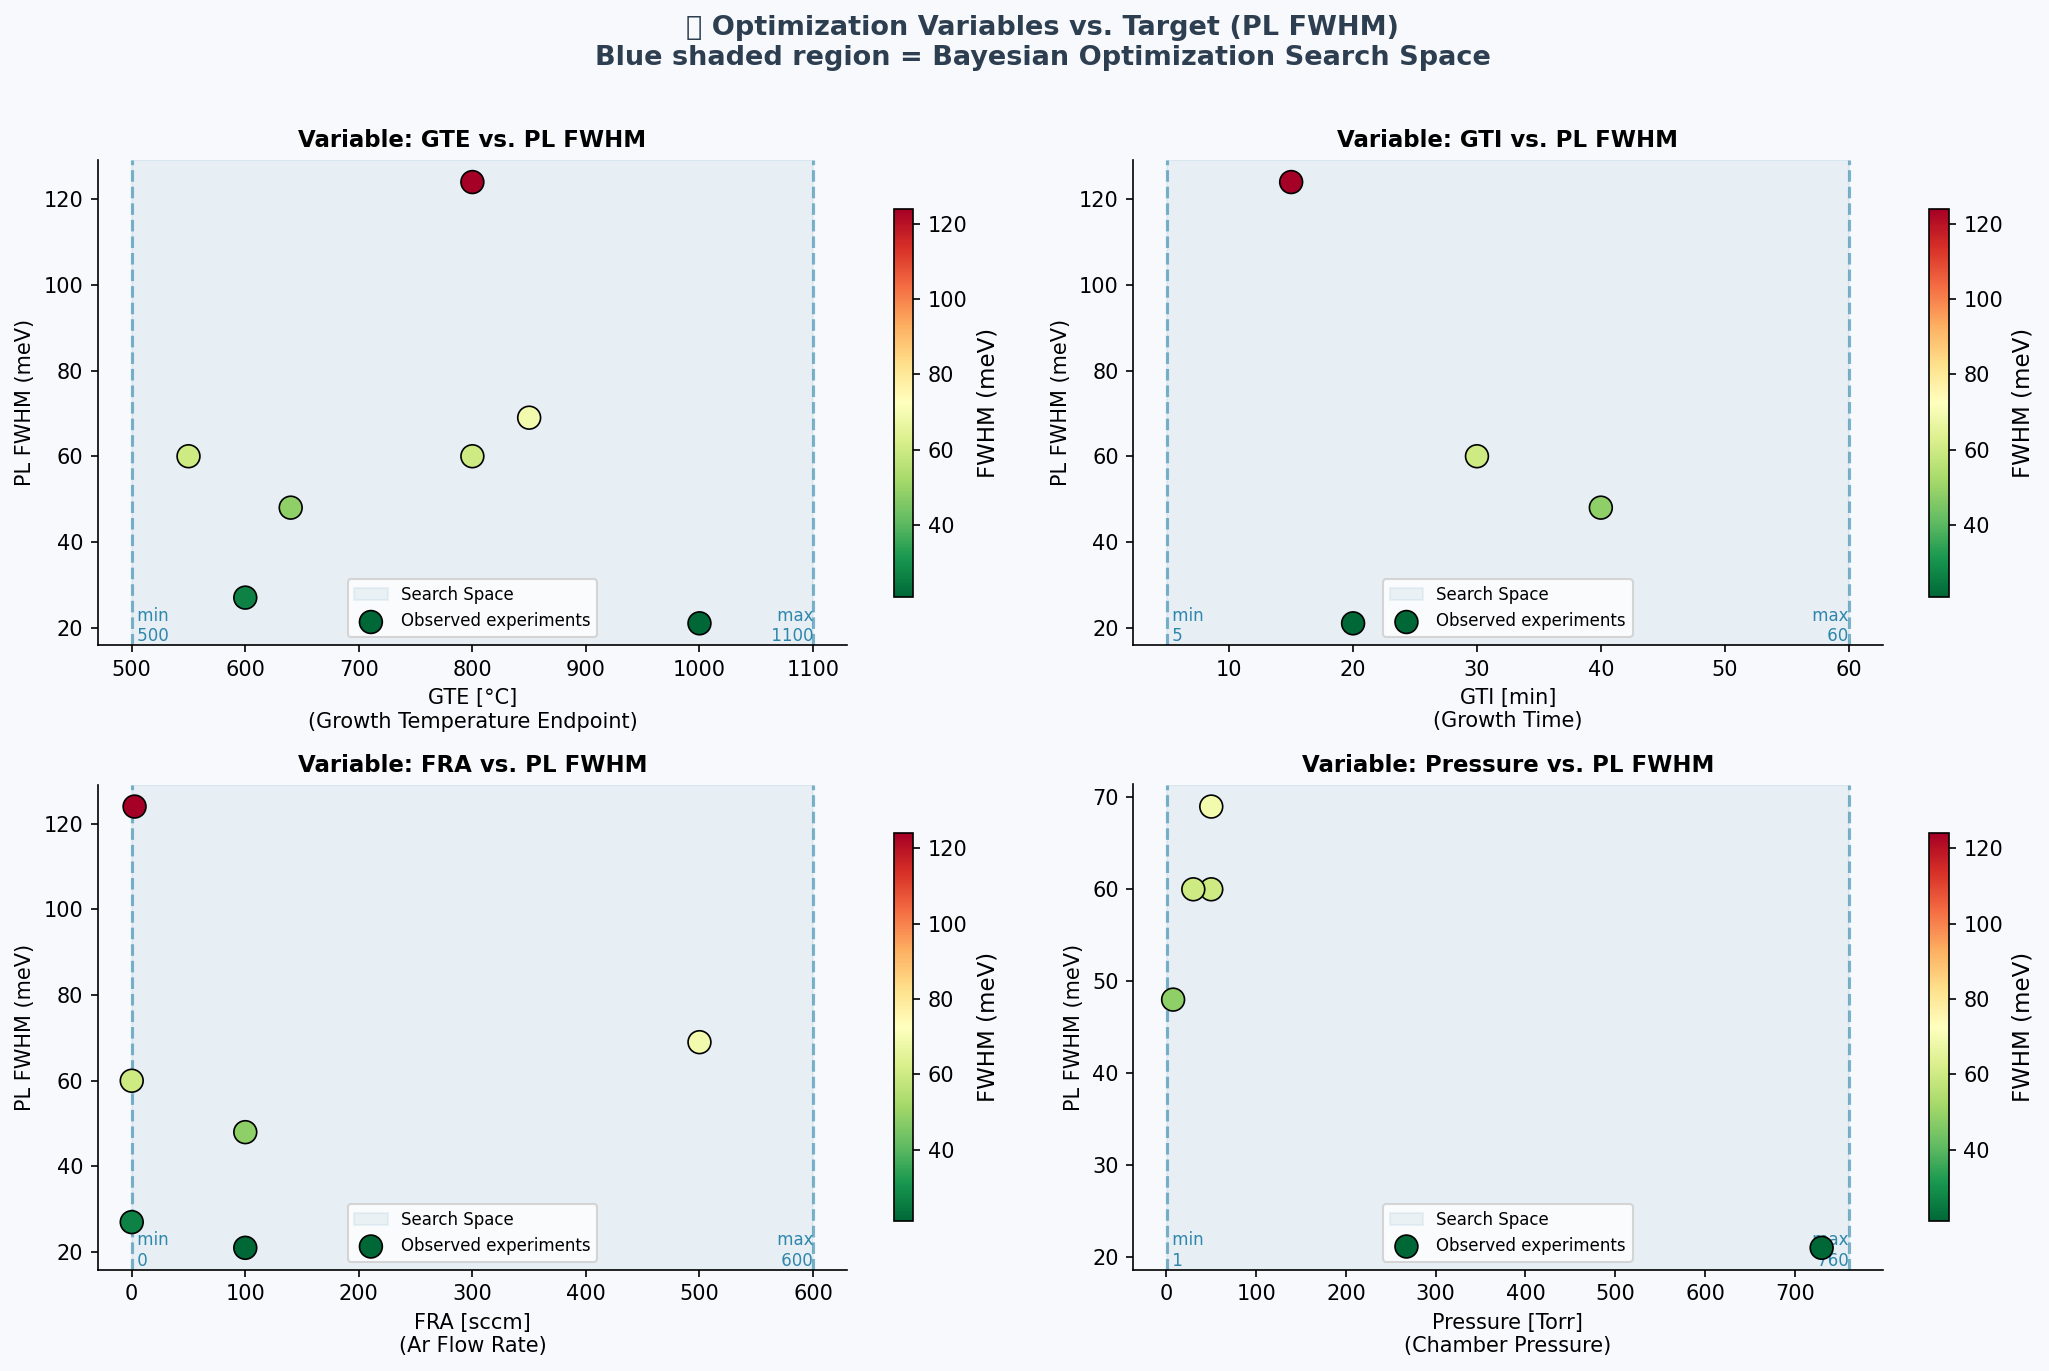

In [7]:
# ─── Numerical Variable Distributions with Search Space ─────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.patch.set_facecolor(COLORS['bg'])
axes = axes.flatten()

for idx, (name, info) in enumerate(VARIABLES.items()):
    ax = axes[idx]
    col = info['col']
    vals = pd.to_numeric(df[col], errors='coerce').dropna()

    # Search space background
    ax.axvspan(info['min'], info['max'], alpha=0.08, color=COLORS['primary'], label='Search Space')

    # Observed data points
    fwhm = df.loc[vals.index, TARGET].values
    sc = ax.scatter(vals, fwhm, c=fwhm, cmap='RdYlGn_r', s=120,
                    edgecolors='black', linewidths=0.8, zorder=5,
                    vmin=df[TARGET].min(), vmax=df[TARGET].max(), label='Observed experiments')
    plt.colorbar(sc, ax=ax, label='FWHM (meV)', shrink=0.8)

    # Add vertical bounds
    ax.axvline(info['min'], color=COLORS['primary'], linestyle='--', alpha=0.6, lw=1.5)
    ax.axvline(info['max'], color=COLORS['primary'], linestyle='--', alpha=0.6, lw=1.5)
    ax.text(info['min'], ax.get_ylim()[0] if ax.get_ylim()[0]>0 else 15,
            f' min\n {info["min"]}', fontsize=8, color=COLORS['primary'], va='bottom')
    ax.text(info['max'], ax.get_ylim()[0] if ax.get_ylim()[0]>0 else 15,
            f' max\n {info["max"]}', fontsize=8, color=COLORS['primary'], va='bottom', ha='right')

    ax.set_xlabel(f'{name} [{info["unit"]}]\n({info["description"]})', fontsize=10)
    ax.set_ylabel('PL FWHM (meV)', fontsize=10)
    ax.set_title(f'Variable: {name} vs. PL FWHM', fontsize=11, fontweight='bold')
    ax.set_facecolor(COLORS['bg'])
    ax.legend(fontsize=8)

fig.suptitle('🎯 Optimization Variables vs. Target (PL FWHM)\nBlue shaded region = Bayesian Optimization Search Space',
             fontsize=13, fontweight='bold', color='#2C3E50', y=1.01)
plt.tight_layout()
plt.savefig('variables_vs_fwhm.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()


---
## 🧱 Step 6: Build Feature Matrix (X) and Target Vector (y)

The feature matrix combines:
- **Encoded categorical constants** (one number per category — same for all rows in fixed-setup mode)
- **Numerical variable values** (the 4 optimization variables)
- **Scaled** to zero mean, unit variance for GP stability


✅ Feature Matrix Built!
   Shape: (7, 12) (7 experiments × 12 features)
   Features: ['P1_enc', 'P2_enc', 'Substrate_enc', 'CG_enc', 'COM_enc', 'PC_enc', 'SA_enc', 'Class_enc', 'GTE', 'GTI', 'FRA', 'Pressure']
   Target (FWHM): [ 21. 124.  60.  69.  27.  48.  60.] meV
   Complete rows (no missing variables): 3/7


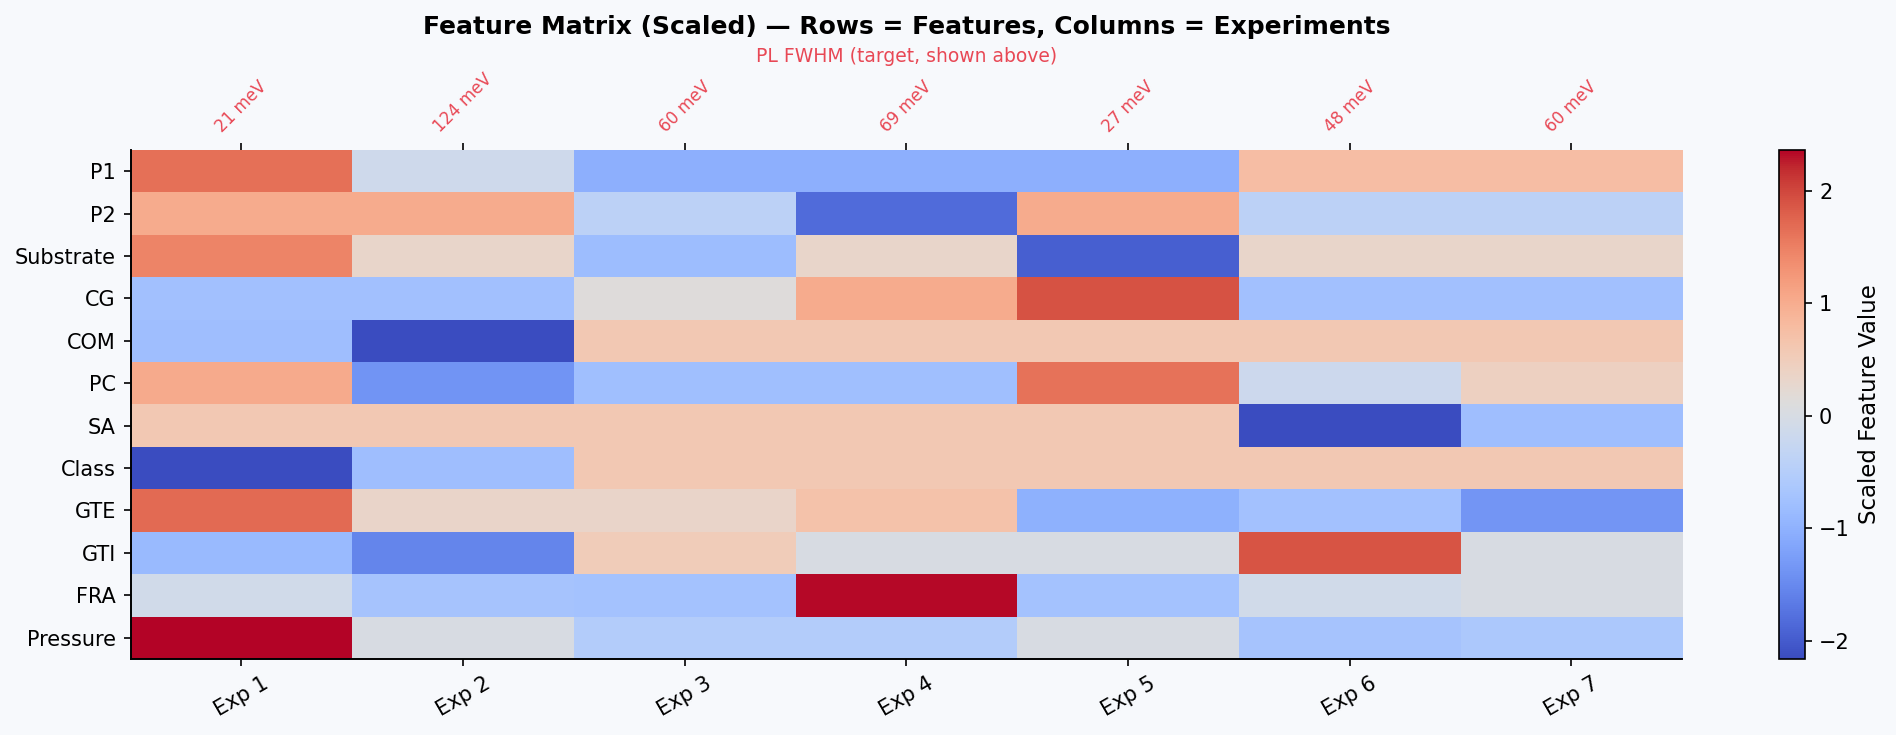

In [8]:
# ─── STEP 4: ENCODE — Matches app's ThermalCVDEncoder.fit_on_data() ─────────

# 1. Fit categorical LabelEncoders (fill NaN with 'Unknown')
label_encoders = {}
constant_values = {}

for col in CAT_CONSTANTS:
    series = df[col].fillna('Unknown').astype(str)
    le = LabelEncoder()
    le.fit(series.unique())
    label_encoders[col] = le
    constant_values[col] = series.mode()[0]
    print(f'   {col:12s} | Fixed at: {repr(constant_values[col]):20s} | Options: {list(le.classes_)}')

# 2. Store numerical constant medians for reference
for col in NUM_CONSTANTS:
    if col in df.columns:
        val = pd.to_numeric(df[col], errors='coerce').dropna()
        constant_values[col] = float(val.median()) if len(val) > 0 else 0.0
    else:
        constant_values[col] = 0.0

print()


---
## 🤖 Step 7: Gaussian Process Surrogate Model

### How the GP Works:
A **Gaussian Process** is a probabilistic model that:
- Fits a distribution over possible functions
- At any new point, gives both a **predicted mean** (best estimate) and **uncertainty** (confidence interval)
- Uses a **kernel** (covariance function) to encode smoothness assumptions — we use the **Matérn 5/2** kernel, which works well for physical processes

$$f(x) \sim \mathcal{GP}\left(\mu(x),\, k(x,x')\right)$$


In [9]:
# ─── STEP 7: GP KERNEL & MODEL ───────────────────────────────────────────────
# EXACT same kernel as app's ThermalCVDGPModel in gp_model.py:
#   ConstantKernel(1.0, (0.1, 10.0))
#   * Matern(length_scale=[1.0,1.0,1.0,1.0], length_scale_bounds=(0.1, 10.0), nu=2.5)
#   + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-4, 1e-1))
# n_restarts_optimizer=15, normalize_y=True, random_state=42

kernel = (
    C(1.0, (0.1, 10.0))
    * Matern(length_scale=[1.0, 1.0, 1.0, 1.0], length_scale_bounds=(0.1, 10.0), nu=2.5)
    + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-4, 1e-1))
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=15,
    normalize_y=True,
    random_state=42
)
gp.fit(X_scaled, y_scaled)

# Predict on training data (in scaled space, then inverse-transform)
y_pred_scaled, y_std_scaled = gp.predict(X_scaled, return_std=True)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_std  = y_std_scaled * scaler_y.scale_[0]

# Cross-validate (LOO for small dataset)
loo = LeaveOneOut()
scores = cross_val_score(gp, X_scaled, y_scaled, cv=loo, scoring='r2')

print('✅ GP Model Trained! (Exact app logic: ARD Matern nu=2.5 + WhiteKernel)')
print(f'   Kernel (optimized): {gp.kernel_}')
print(f'   LOO R² scores: {scores.round(3)}')
print(f'   Mean LOO R²: {scores.mean():.3f}')
print()
print('   Predicted vs Actual FWHM:')
for i, (act, pred, std) in enumerate(zip(y_raw, y_pred, y_std)):
    print(f'   Exp {i+1}: Actual={act:.0f} meV | Predicted={pred:.1f} ± {std:.1f} meV')


✅ GP Model Trained!
   Kernel (optimized): 1**2 * Matern(length_scale=0.0421, nu=2.5) + WhiteKernel(noise_level=8.63e-05)
   LOO R² scores: [nan nan nan nan nan nan nan]
   Mean LOO R²: nan

   Predicted vs Actual FWHM:
   Exp 1: Actual=21 meV | Predicted=21.0 ± 0.4 meV
   Exp 2: Actual=124 meV | Predicted=124.0 ± 0.4 meV
   Exp 3: Actual=60 meV | Predicted=60.0 ± 0.4 meV
   Exp 4: Actual=69 meV | Predicted=69.0 ± 0.4 meV
   Exp 5: Actual=27 meV | Predicted=27.0 ± 0.4 meV
   Exp 6: Actual=48 meV | Predicted=48.0 ± 0.4 meV
   Exp 7: Actual=60 meV | Predicted=60.0 ± 0.4 meV


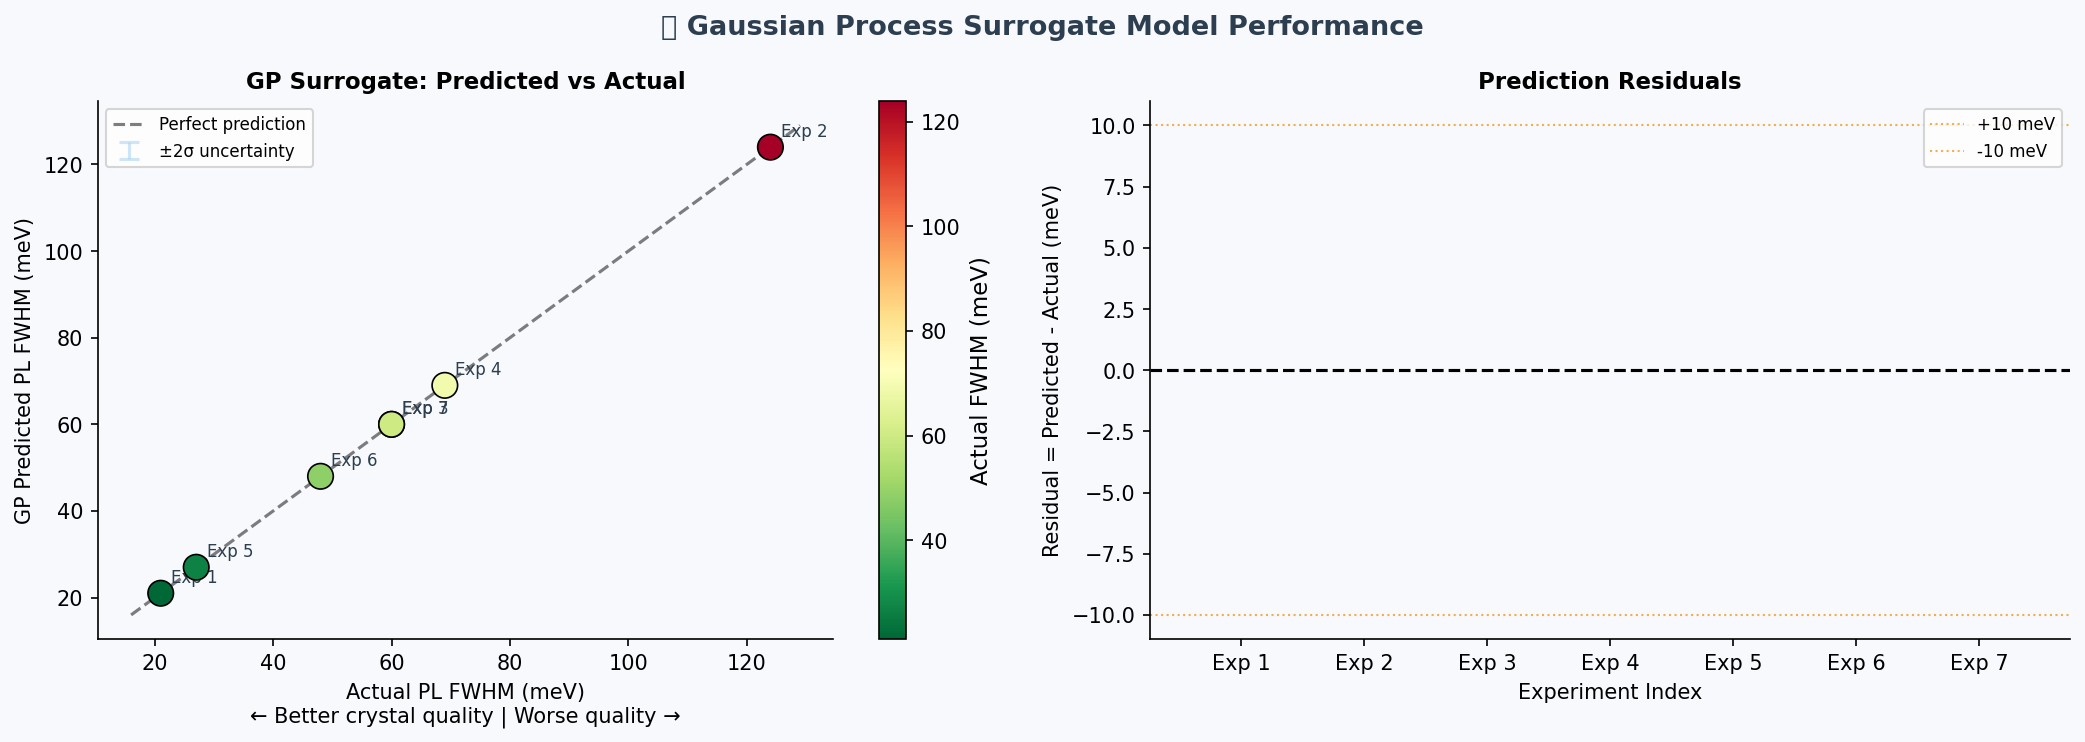

In [10]:
# ─── GP Fit Visualization: Predicted vs Actual ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(COLORS['bg'])

# Left: Predicted vs Actual
ax = axes[0]
ax.errorbar(y_raw, y_pred, yerr=2*y_std, fmt='none',
            color=COLORS['gp_ci'], alpha=0.6, capsize=5, capthick=1.5, label='±2σ uncertainty')
sc = ax.scatter(y_raw, y_pred, c=y_raw, cmap='RdYlGn_r', s=150,
                edgecolors='black', linewidths=0.8, zorder=5,
                vmin=y_raw.min(), vmax=y_raw.max())
plt.colorbar(sc, ax=ax, label='Actual FWHM (meV)')

for i, (xa, xp) in enumerate(zip(y_raw, y_pred)):
    ax.annotate(f'Exp {i+1}', (xa, xp), textcoords='offset points',
                xytext=(5, 5), fontsize=8, color='#2C3E50')

lims = [min(y_raw.min(), y_pred.min())-5, max(y_raw.max(), y_pred.max())+5]
ax.plot(lims, lims, 'k--', lw=1.5, alpha=0.5, label='Perfect prediction')
ax.set_xlabel('Actual PL FWHM (meV)\n← Better crystal quality | Worse quality →', fontsize=10)
ax.set_ylabel('GP Predicted PL FWHM (meV)', fontsize=10)
ax.set_title('GP Surrogate: Predicted vs Actual', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.set_facecolor(COLORS['bg'])

# Right: Residuals
ax2 = axes[1]
residuals = y_pred - y_raw
colors_res = [COLORS['success'] if abs(r) < 10 else COLORS['danger'] for r in residuals]
ax2.bar(range(len(residuals)), residuals, color=colors_res, edgecolor='white', linewidth=1)
ax2.axhline(0, color='black', lw=1.5, linestyle='--')
ax2.axhline(10, color=COLORS['accent'], lw=1, linestyle=':', alpha=0.7, label='+10 meV')
ax2.axhline(-10, color=COLORS['accent'], lw=1, linestyle=':', alpha=0.7, label='-10 meV')
ax2.set_xticks(range(len(residuals)))
ax2.set_xticklabels([f'Exp {i+1}' for i in range(len(residuals))])
ax2.set_xlabel('Experiment Index', fontsize=10)
ax2.set_ylabel('Residual = Predicted - Actual (meV)', fontsize=10)
ax2.set_title('Prediction Residuals', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8)
ax2.set_facecolor(COLORS['bg'])

fig.suptitle('🤖 Gaussian Process Surrogate Model Performance',
             fontsize=13, fontweight='bold', color='#2C3E50')
plt.tight_layout()
plt.savefig('gp_performance.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()


---
## 📡 Step 8: Acquisition Function — Expected Improvement (EI)

### What is the Acquisition Function?
The **Expected Improvement (EI)** function balances:
- **Exploitation**: Try points near the current best (low FWHM)
- **Exploration**: Try uncertain regions (high GP std)

$$\text{EI}(\mathbf{x}) = \mathbb{E}\left[\max(f^* - f(\mathbf{x}),\, 0)\right]$$

where $f^*$ is the current best observed FWHM (minimum). The **next experiment** = $\arg\max_{\mathbf{x}}\, \text{EI}(\mathbf{x})$


In [11]:
# ─── STEP 4: ENCODE — Matches app's ThermalCVDEncoder.fit_on_data() ─────────

# 1. Fit categorical LabelEncoders (fill NaN with 'Unknown')
label_encoders = {}
constant_values = {}

for col in CAT_CONSTANTS:
    series = df[col].fillna('Unknown').astype(str)
    le = LabelEncoder()
    le.fit(series.unique())
    label_encoders[col] = le
    constant_values[col] = series.mode()[0]
    print(f'   {col:12s} | Fixed at: {repr(constant_values[col]):20s} | Options: {list(le.classes_)}')

# 2. Store numerical constant medians for reference
for col in NUM_CONSTANTS:
    if col in df.columns:
        val = pd.to_numeric(df[col], errors='coerce').dropna()
        constant_values[col] = float(val.median()) if len(val) > 0 else 0.0
    else:
        constant_values[col] = 0.0

print()


✅ Acquisition Function Computed!
   Current best FWHM: 21 meV (Exp 1)
   Max EI value: 0.055992

🔬 === NEXT SUGGESTED EXPERIMENT ===
   (Dry Run — Fixed Constants)

   GTE       :   724.72 °C      (Growth Temperature Endpoint)
   GTI       :    26.65 min     (Growth Time)
   FRA       :   224.18 sccm    (Ar Flow Rate)
   Pressure  :   380.25 Torr    (Chamber Pressure)

   Constants (fixed for this run):
   P1        : 'W(CO)6'             → code=0
   P2        : 'H2S'                → code=1
   Substrate : 'SiO2/Si'            → code=2
   CG        : 'Ar'                 → code=0
   COM       : 'Unknown'            → code=2
   PC        : 'Bubbler'            → code=1
   SA        : 'Unknown'            → code=2
   Class     : 'Unknown'            → code=2
